In [1]:
import os
from tqdm import tqdm
import glob
import re

import math
import numpy as np
import scipy
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import r2_score

import imageio.v2 as imageio
import torch
import torch.nn.functional as F
from torchvision import transforms

from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor

/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
base_dir = '/home/ri99/ieeg'
ieeg_dir = f'{base_dir}/subjects/111/preproc'
csv_dir = f'{base_dir}/nsd_PTB'
img_dir = f'{base_dir}/nsd_ecog'
cache_dir = f'{base_dir}/.cache'
os.makedirs(cache_dir, exist_ok=True)
sub = 11
n_blocks = -1
n_runs = 56

In [3]:
curric = pd.read_csv(f"{csv_dir}/curriculum_patient{sub}.csv")
# ieeg_mat = scipy.io.loadmat(f"{data_dir}/NSD_sub10{sub}_run1.mat")

In [4]:
display(curric.head())

,Unnamed: 0,filename,inventory,coco_id,is_repeat,repetition_number,block
0,0,special_23715.png,1x-shared1000_A,23715.0,0,1,1
1,1,notspecial_24264.png,1x-shared1000_A,24264.0,0,1,1
2,2,pair_45_w_pagoda1.png,MST,NaN,0,1,1
3,3,pair_33_nsd_777_1_cocoid_68844.png,MST,68844.0,0,1,1
4,4,notspecial_36682.png,3x-shared1000_A,36682.0,0,1,1


In [5]:
# ieeg_mat['data']

In [6]:
if n_blocks == -1:  # use all available blocks
    block_list = curric['block'].unique().astype(str)
else:  # use n_blocks to specify instead
    block_list = [str(x) for x in range(1, n_blocks+1)]

print(block_list)
image_names = list(curric[curric['block'].isin(block_list)]['filename'])
print(len(image_names))

['1' '2' '3' '4' 'filler_block_1' 'filler_block_2']
5600


In [7]:
# wrangle curriculum files
# want: conditions x timepoints matrix
# num conditions = num unique images
# num timepoints = ?

In [8]:
imsize = (224,224)
resize_transform = transforms.Resize(imsize)
data_type = torch.float32

images = torch.empty((len(image_names), 3, imsize[0], imsize[1]), dtype=data_type)

assert len(image_names) == len(curric['block'])
for i, im_name in tqdm(enumerate(image_names), total=len(image_names)):
    default_path = f"{img_dir}/stimulusfiles/{im_name}"
    if not os.path.exists(default_path):  # non-default case; image isn't in stimulusfiles
        candidates = glob.glob(f"{img_dir}/**/{im_name}", recursive=True)
    
        if len(candidates) == 0:
            raise FileNotFoundError(f"No matching files found for {im_name} under {img_dir}")
    
        imgs = [imageio.imread(path) for path in candidates]
    
        # check for identical matches
        if len(imgs) > 1:
            for j in range(1, len(imgs)):
                if not np.array_equal(imgs[0], imgs[j]):
                    raise ValueError(f"Non-identical duplicates found for {im_name}:\n{candidates}")
    
        im = imgs[0]
    else:  # default case; image in stimulusfiles
        im = imageio.imread(default_path)

    if im.ndim == 2:
        im = np.stack([im]*3, axis=-1)
    elif im.shape[2] == 4:
        im = im[:, :, :3]
    im = torch.tensor(im, dtype=data_type).permute(2,0,1)
    im = resize_transform(im)
    images[i] = im

print(images.shape, type(images), images.dtype)
print(images.min(), images.max())

100%|██████████| 5600/5600 [00:45<00:00, 121.78it/s]


torch.Size([5600, 3, 224, 224]) <class 'torch.Tensor'> torch.float32
tensor(0.) tensor(255.0001)


In [41]:
run_list = list(range(1, n_runs+1))

all_data = []
all_labels = []
time_ref = None

for run in tqdm(run_list):
    data = np.load(f"{ieeg_dir}/data/NSD_sub1{sub}_run{run}_data.npy")
    labels = pd.read_csv(f"{ieeg_dir}/labels/NSD_sub1{sub}_run{run}_labels.csv")
    time = np.load(f"{ieeg_dir}/time/NSD_sub1{sub}_run{run}_time.npy")

    assert time.shape[0] == data.shape[2], f"time mismatch in run {run}"
    assert labels.shape[0] == data.shape[1], f"label mismatch in run {run}"

    assert labels['channel_name'].iloc[168] == 'ECG1'
    
    if time_ref is None:
        time_ref = time
    else:
        assert np.allclose(time, time_ref), f"time array differs in run {run}"

    all_data.append(data)
    all_labels.append(labels)

# stack along the trial axis (axis=0)
ieeg_data = np.concatenate(all_data, axis=0)
ieeg_labels = pd.concat(all_labels, ignore_index=True)
ieeg_time = time_ref

print(f"ieeg_data shape: {ieeg_data.shape}")
print(f"ieeg_labels shape: {ieeg_labels.shape}")
print(f"ieeg_time shape: {ieeg_time.shape}")

print('dropping all channels including and after ECG1')
ieeg_labels = ieeg_labels.iloc[:168]
ieeg_data = ieeg_data[:, :168]

# print('dropping data before stimulus onset')
# ieeg_data = ieeg_data[:, :, ieeg_time > 0]
# ieeg_time = ieeg_time[ieeg_time > 0]

print(f"ieeg_data shape: {ieeg_data.shape}")
print(f"ieeg_labels shape: {ieeg_labels.shape}")
print(f"ieeg_time shape: {ieeg_time.shape}")

if images.shape[0] != ieeg_data.shape[0]:
    pass
    # images = images[:ieeg_data.shape[0]]
    # print("Dropped images based on available data.")
    # print(f"New images shape: {images.shape}")

assert images.shape[0] == ieeg_data.shape[0]

100%|██████████| 56/56 [00:07<00:00,  7.95it/s]


ieeg_data shape: (5600, 276, 564)
ieeg_labels shape: (15456, 2)
ieeg_time shape: (564,)
dropping all channels including and after ECG1
ieeg_data shape: (5600, 168, 564)
ieeg_labels shape: (168, 2)
ieeg_time shape: (564,)


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

image_encoder = CLIPVisionModelWithProjection.from_pretrained(
            "laion/CLIP-ViT-H-14-laion2B-s32B-b79K", cache_dir=cache_dir
        ).to(device)
feature_extractor = CLIPImageProcessor(size=224, crop_size=224)

Using device: cuda


In [11]:
# TODO reshape to condition x electrode x repetition x time, nan padding for repeats

In [50]:
# Get stimulus repetition information based on NSD ID only
stim_counts = curric['coco_id'].value_counts()
unique_stimuli = stim_counts.index.tolist()
n_unique_images = len(unique_stimuli)
max_repeats = stim_counts.max()

print(f"Number of unique stimuli: {n_unique_images}")
print(f"Maximum repetitions per stimulus: {max_repeats}")
print(f"Repetition distribution:")
print(stim_counts.value_counts().sort_index())

# Initialize reshaped array
_, n_channels, n_timepoints = ieeg_data.shape
reshaped_data = np.full((n_channels, n_unique_images, n_timepoints, max_repeats), 
                       np.nan, dtype=ieeg_data.dtype)

# Create mapping from stimulus NSD ID to trial indices
stimulus_to_trials = {}
for trial_idx, nsd_id in enumerate(curric['coco_id']):
    if nsd_id not in stimulus_to_trials:
        stimulus_to_trials[nsd_id] = []
    stimulus_to_trials[nsd_id].append(trial_idx)

# Fill the reshaped array
for img_idx, stimulus in enumerate(unique_stimuli):
    trial_indices = stimulus_to_trials[stimulus]
    
    # Copy data for all repetitions of this stimulus
    for repeat_idx, trial_idx in enumerate(trial_indices):
        reshaped_data[:, img_idx, :, repeat_idx] = ieeg_data[trial_idx]
    
    if img_idx % 100 == 0:
        print(f"Processed {img_idx+1}/{n_unique_images} stimuli...")

Number of unique stimuli: 2838
Maximum repetitions per stimulus: 4
Repetition distribution:
count
1     800
2    1600
3     400
4      38
Name: count, dtype: int64
Processed 1/2838 stimuli...
Processed 101/2838 stimuli...
Processed 201/2838 stimuli...
Processed 301/2838 stimuli...
Processed 401/2838 stimuli...
Processed 501/2838 stimuli...
Processed 601/2838 stimuli...
Processed 701/2838 stimuli...
Processed 801/2838 stimuli...
Processed 901/2838 stimuli...
Processed 1001/2838 stimuli...
Processed 1101/2838 stimuli...
Processed 1201/2838 stimuli...
Processed 1301/2838 stimuli...
Processed 1401/2838 stimuli...
Processed 1501/2838 stimuli...
Processed 1601/2838 stimuli...
Processed 1701/2838 stimuli...
Processed 1801/2838 stimuli...
Processed 1901/2838 stimuli...
Processed 2001/2838 stimuli...
Processed 2101/2838 stimuli...
Processed 2201/2838 stimuli...
Processed 2301/2838 stimuli...
Processed 2401/2838 stimuli...
Processed 2501/2838 stimuli...
Processed 2601/2838 stimuli...
Processed 2

In [11]:
batch_size = 32
clip_embeds = []

for i in tqdm(range(0, len(images), batch_size), desc="Generating CLIP embeddings"):
    # generate embeddings using GPU in batches, then offload each batch to CPU to prevent GPU memory overflow
    batch = images[i:i + batch_size]
    
    inputs = feature_extractor(
        images=[im.byte().permute(1,2,0).numpy() for im in batch],
        return_tensors='pt', do_rescale=True
    )
    inputs['pixel_values'] = inputs['pixel_values'].to(device)

    with torch.inference_mode():
        outputs = image_encoder(**inputs)
        clip_embeds.append(outputs.image_embeds.cpu())

clip_image = torch.cat(clip_embeds, dim=0)
print(f"clip embeddings shape: {clip_image.shape}")

Generating CLIP embeddings: 100%|██████████| 175/175 [03:12<00:00,  1.10s/it]

clip embeddings shape: torch.Size([5600, 1024])


In [31]:
# TODO np unique to get unique coco ids and indices

np.int64(6800)

In [45]:
unique_images, unique_image_counts = np.unique(image_names, return_counts=True)

In [46]:
print(unique_images[:5], unique_image_counts[:5])

['notspecial_10393.png' 'notspecial_10507.png' 'notspecial_10586.png'
 'notspecial_10600.png' 'notspecial_10610.png'] [1 1 1 1 3]


In [47]:
def compute_noise_ceiling(data_in):
    """
    Compute the noise ceiling signal-to-noise ratio (NCSNR) and percentage noise ceiling for each channel.
    
    Parameters:
        data_in (array): Data with shape (channels, conditions, trials), where each channel has more than 1 trial per condition.
    
    Returns:
        noise_ceiling (array): Noise ceiling as a percentage for each channel.
        ncsnr (array): Noise ceiling SNR for each channel.
        signal_var (array): Signal variance for each channel.
        noise_var (array): Noise variance for each channel.
    """
    
    # Calculate noise variance as mean variance across trials for each channel
    noise_var = np.mean(np.var(data_in, axis=2, ddof=1), axis=1)
    
    # Calculate data variance as variance of the trial means across conditions for each channel
    data_var = np.var(np.mean(data_in, axis=2), axis=1, ddof=1)
    
    # Calculate signal variance by subtracting noise variance from data variance
    signal_var = np.maximum(data_var - noise_var / data_in.shape[2], 0)  # Ensure non-negative variance
    
    # Compute noise ceiling SNR
    ncsnr = np.sqrt(signal_var) / np.sqrt(noise_var)
    
    # Calculate noise ceiling as percentage based on SNR
    noise_ceiling = 100 * (ncsnr ** 2 / (ncsnr ** 2 + 1 / data_in.shape[2]))
    
    return noise_ceiling, ncsnr, signal_var, noise_var


def compute_ncsnr_all_timepoints(data_4d, times):
    """
    Compute NCSNR and NC percentage for every channel at every timepoint.
    
    Parameters:
        data_4d (array): Data with shape (conditions, channels, trials, timepoints)
        times (array): Time array in milliseconds
    
    Returns:
        ncsnr_results (array): NCSNR for each channel and timepoint (channels, timepoints)
        nc_results (array): Noise ceiling percentage for each channel and timepoint (channels, timepoints)
    """
    
    n_conditions, n_channels, n_trials, n_timepoints = data_4d.shape
    
    # Initialize result arrays
    ncsnr_results = np.zeros((n_channels, n_timepoints))
    nc_results = np.zeros((n_channels, n_timepoints))
    
    print(f"Computing NCSNR for {n_channels} channels across {n_timepoints} timepoints...")
    
    # Iterate through each timepoint
    for t in range(n_timepoints):
        if t % 100 == 0:  # Progress indicator
            print(f"Processing timepoint {t+1}/{n_timepoints} ({times[t]:.1f}ms)")
        
        # Extract data for this timepoint: (conditions, channels, trials)
        timepoint_data = data_4d[:, :, :, t]  # (conditions, channels, trials)
        
        # Transpose to (channels, conditions, trials) for compute_noise_ceiling
        reshaped_data = timepoint_data.transpose(1, 0, 2)  # (channels, conditions, trials)
        
        # Compute noise ceiling for this timepoint
        noise_ceiling, ncsnr, _, _ = compute_noise_ceiling(reshaped_data)
        
        # Store results
        ncsnr_results[:, t] = ncsnr
        nc_results[:, t] = noise_ceiling
    
    print("NCSNR computation complete!")
    return ncsnr_results, nc_results


def ncsnr_figs(ncsnr_all, nc_all, times):

    print(f"NCSNR results shape: {ncsnr_all.shape}") 
    print(f"NC results shape: {nc_all.shape}")      

    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('NCSNR and Noise Ceiling Analysis Across All Timepoints', fontsize=16)

    # 1. NCSNR heatmap: channels × time
    im1 = axes[0,0].imshow(ncsnr_all, aspect='auto', cmap='viridis', 
                        extent=[times[0], times[-1], nc_all.shape[0], 1], interpolation='none')
    axes[0,0].set_title('NCSNR Heatmap (Channels × Time)')
    axes[0,0].set_xlabel('Time (s)')
    axes[0,0].set_ylabel('Channel')
    axes[0,0].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    plt.colorbar(im1, ax=axes[0, 0], label='NCSNR')

    # 2. Noise Ceiling heatmap: channels × time
    im2 = axes[0, 1].imshow(nc_all, aspect='auto', cmap='plasma', 
                        extent=[times[0], times[-1], nc_all.shape[0], 1], interpolation='none')
    axes[0, 1].set_title('Noise Ceiling % Heatmap (Channels × Time)')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Channel')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    plt.colorbar(im2, ax=axes[0, 1], label='Noise Ceiling %')

    # 3. Mean NCSNR across channels vs time
    mean_ncsnr_time = np.nanmedian(ncsnr_all, axis=0)
    axes[1,0].plot(times, mean_ncsnr_time, 'b-', linewidth=2)
    axes[1,0].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[1,0].set_title('Mean NCSNR Across Channels vs Time')
    axes[1,0].set_xlabel('Time (s)')
    axes[1,0].set_ylabel('Mean NCSNR')
    axes[1,0].grid(True, alpha=0.3)

    # 4. Mean Noise Ceiling across channels vs time
    mean_nc_time = np.nanmedian(nc_all, axis=0)
    axes[1, 1].plot(times, mean_nc_time, 'r-', linewidth=2)
    axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
    axes[1, 1].set_title('Mean Noise Ceiling % Across Channels vs Time')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Mean Noise Ceiling %')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"Mean NCSNR across all channels and time: {np.nanmean(ncsnr_all):.3f}")
    print(f"Max NCSNR: {np.nanmax(ncsnr_all):.3f}")
    print(f"Mean Noise Ceiling across all channels and time: {np.nanmean(nc_all):.1f}%")
    print(f"Max Noise Ceiling: {np.nanmax(nc_all):.1f}%")

    # Find peak times
    peak_ncsnr_time_idx = np.argmax(mean_ncsnr_time)
    peak_nc_time_idx = np.argmax(mean_nc_time)
    print(f"Peak NCSNR time: {times[peak_ncsnr_time_idx]:.1f}ms")
    print(f"Peak NC time: {times[peak_nc_time_idx]:.1f}ms")

In [72]:
def reshape_electrode_data_by_stimuli(electrode_data, events_df, stim_column='stim_file'):
    """
    Reshape electrode data from (channels, time, trials) to (channels, images, time, repeats)
    based on repeated stimuli in events dataframe.
    
    Parameters:
        electrode_data: array of shape (channels, time, trials) 
        events_df: DataFrame with stimulus information
        stim_column: column name containing stimulus identifiers
    
    Returns:
        reshaped_data: array of shape (channels, n_unique_images, time, max_repeats)
        stimulus_info: dict with stimulus mapping information
    """
    import re
    
    print(f"Original electrode data shape: {electrode_data.shape}")
    print(f"Events dataframe shape: {events_df.shape}")
    
    # Extract NSD ID from the stimulus file path (e.g., _nsd59080_)
    events_df_copy = events_df.copy()
    
    def extract_nsd_id(filepath):
        """Extract NSD ID from filepath like /path/to/_nsd59080_.png -> nsd59080"""
        match = re.search(r'(\d+)_', filepath)
        return f"coco{match.group(1)}" if match else filepath
    
    events_df_copy['coco_id'] = events_df_copy[stim_column].apply(extract_nsd_id)
    
    # Get stimulus repetition information based on NSD ID only
    stim_counts = events_df_copy['coco_id'].value_counts()
    unique_stimuli = stim_counts.index.tolist()
    n_unique_images = len(unique_stimuli)
    max_repeats = stim_counts.max()
    
    print(f"Number of unique stimuli: {n_unique_images}")
    print(f"Maximum repetitions per stimulus: {max_repeats}")
    print(f"Repetition distribution:")
    print(stim_counts.value_counts().sort_index())
    
    # Initialize reshaped array
    n_channels, n_timepoints, n_trials = electrode_data.shape
    reshaped_data = np.full((n_channels, n_unique_images, n_timepoints, max_repeats), 
                           np.nan, dtype=electrode_data.dtype)
    
    # Create mapping from stimulus NSD ID to trial indices
    stimulus_to_trials = {}
    for trial_idx, nsd_id in enumerate(events_df_copy['nsd_id']):
        if nsd_id not in stimulus_to_trials:
            stimulus_to_trials[nsd_id] = []
        stimulus_to_trials[nsd_id].append(trial_idx)
    
    # Fill the reshaped array
    for img_idx, stimulus in enumerate(unique_stimuli):
        trial_indices = stimulus_to_trials[stimulus]
        
        # Copy data for all repetitions of this stimulus
        for repeat_idx, trial_idx in enumerate(trial_indices):
            reshaped_data[:, img_idx, :, repeat_idx] = electrode_data[:, :, trial_idx]
        
        if img_idx % 100 == 0:
            print(f"Processed {img_idx+1}/{n_unique_images} stimuli...")
    
    # Create stimulus info dictionary
    stimulus_info = {
        'unique_stimuli': unique_stimuli,
        'stimulus_counts': stim_counts.to_dict(),
        'stimulus_to_trials': stimulus_to_trials,
        'max_repeats': max_repeats,
        'n_unique_images': n_unique_images,
        'nsd_id_mapping': dict(zip(events_df_copy['nsd_id'], events_df_copy[stim_column]))
    }
    
    print(f"Final reshaped data shape: {reshaped_data.shape}")
    print(f"Shape interpretation: ({n_channels} channels, {n_unique_images} images, {n_timepoints} timepoints, {max_repeats} max repeats)")
    
    return reshaped_data, stimulus_info

In [74]:
ieeg_data.shape

(5600, 168, 564)

In [ ]:
# First, reshape your electrode data using the existing function
reshaped_electrode_data, stim_info = reshape_electrode_data_by_stimuli(
    ieeg_data,  # Your electrode data (channels, time, trials)
    events_df,         # Your events dataframe
    stim_column='stim_file'
)

In [73]:
def extract_images_with_n_repeats(reshaped_data, stim_info, n_repeats=6):
    """
    Extract data for images that have exactly n_repeats repetitions.
    
    Parameters:
        reshaped_data: array of shape (channels, n_unique_images, time, max_repeats)
        stim_info: dict with stimulus mapping information from reshape_electrode_data_by_stimuli
        n_repeats: number of repeats to filter for (default=6)
    
    Returns:
        filtered_data: array of shape (channels, n_filtered_images, time, n_repeats)
        filtered_stimuli: list of stimulus IDs that have exactly n_repeats
        filtered_indices: list of original indices in reshaped_data
    """
    
    # Find stimuli with exactly n_repeats
    filtered_stimuli = []
    filtered_indices = []
    
    for i, stimulus in enumerate(stim_info['unique_stimuli']):
        if stim_info['stimulus_counts'][i] == n_repeats:
            filtered_stimuli.append(stimulus)
            filtered_indices.append(i)
    
    print(f"Found {len(filtered_stimuli)} images with exactly {n_repeats} repeats")
    
    if len(filtered_stimuli) == 0:
        print(f"No images found with exactly {n_repeats} repeats")
        return None, [], []
    
    # Extract data for these images
    n_channels, _, n_timepoints, _ = reshaped_data.shape
    filtered_data = np.zeros((n_channels, len(filtered_stimuli), n_timepoints, n_repeats))
    
    from IPython.core.debugger import set_trace
    for new_idx, orig_idx in enumerate(filtered_indices):
        # set_trace()
        print(new_idx, orig_idx)
        assert np.mean(np.isnan(reshaped_data[:, orig_idx, :, :n_repeats])) == 0
        filtered_data[:, new_idx, :, :] = reshaped_data[:, orig_idx, :, :n_repeats]
    
    print(f"Extracted data shape: {filtered_data.shape}")
    print(f"Shape interpretation: ({n_channels} channels, {len(filtered_stimuli)} images, {n_timepoints} timepoints, {n_repeats} repeats)")
    
    return filtered_data, filtered_stimuli, filtered_indices

In [51]:
reshaped_data.shape

(168, 2838, 564, 4)

In [52]:
stim_info['stimulus_counts'][0].item()

1

In [53]:
stim_info = {'stimulus_counts': unique_image_counts, 'unique_stimuli': unique_images}

In [69]:
# Then extract images with exactly 6 repeats
filtered_3_repeats, stimuli_3_repeats, indices_3_repeats = extract_images_with_n_repeats(
    reshaped_data, 
    stim_info, 
    n_repeats=3
)

# Check the result
print(f"Filtered data shape: {filtered_3_repeats.shape}")
print(f"Number of stimuli with 3 repeats: {len(stimuli_3_repeats)}")

Found 400 images with exactly 3 repeats
0 4
1 7
2 9
3 11
4 13
5 16
6 17
7 19
8 22
9 24
10 26
11 27
12 28
13 33
14 34
15 37
16 38
17 39
18 41
19 44
20 56
21 58
22 59
23 61
24 62
25 65
26 67
27 69
28 70
29 72
30 76
31 78
32 80
33 83
34 84
35 88
36 89
37 91
38 95
39 99
40 102
41 103
42 104
43 113
44 114
45 115
46 116
47 118
48 119
49 120
50 126
51 134
52 135
53 138
54 139
55 140
56 142
57 146
58 148
59 149
60 150
61 156
62 157
63 161
64 162
65 164
66 167
67 168
68 170
69 171
70 172
71 176
72 177
73 178
74 180
75 181
76 184
77 187
78 188
79 190
80 191
81 193
82 196
83 198
84 200
85 202
86 205
87 206
88 208
89 213
90 218
91 220
92 222
93 223
94 224
95 225
96 227
97 229
98 230
99 232
100 234
101 236
102 244
103 245
104 248
105 258
106 260
107 264
108 268
109 271
110 275
111 276
112 279
113 283
114 287
115 290
116 291
117 292
118 293
119 294
120 297
121 299
122 300
123 302
124 304
125 307
126 309
127 313
128 314
129 316
130 317
131 319
132 320
133 321
134 322
135 324
136 326
137 331
138 332
1

AssertionError: 

In [70]:
reshaped_data.shape

(168, 2838, 564, 4)

Original filtered data shape: (168, 400, 564, 3)
Transposed data shape: (400, 168, 3, 564)
Shape interpretation: (400 conditions/images, 168 channels, 3 trials/repeats, 564 timepoints)
Times array shape: (564,)
Computing NCSNR for 168 channels across 564 timepoints...
Processing timepoint 1/564 (-0.2ms)
Processing timepoint 101/564 (0.2ms)
Processing timepoint 201/564 (0.6ms)
Processing timepoint 301/564 (1.0ms)
Processing timepoint 401/564 (1.4ms)
Processing timepoint 501/564 (1.8ms)
NCSNR computation complete!
NCSNR results shape: (168, 564)
NC results shape: (168, 564)


/tmp/ipykernel_804958/39888123.py:104: RuntimeWarning: All-NaN slice encountered
  mean_ncsnr_time = np.nanmedian(ncsnr_all, axis=0)
/tmp/ipykernel_804958/39888123.py:113: RuntimeWarning: All-NaN slice encountered
  mean_nc_time = np.nanmedian(nc_all, axis=0)


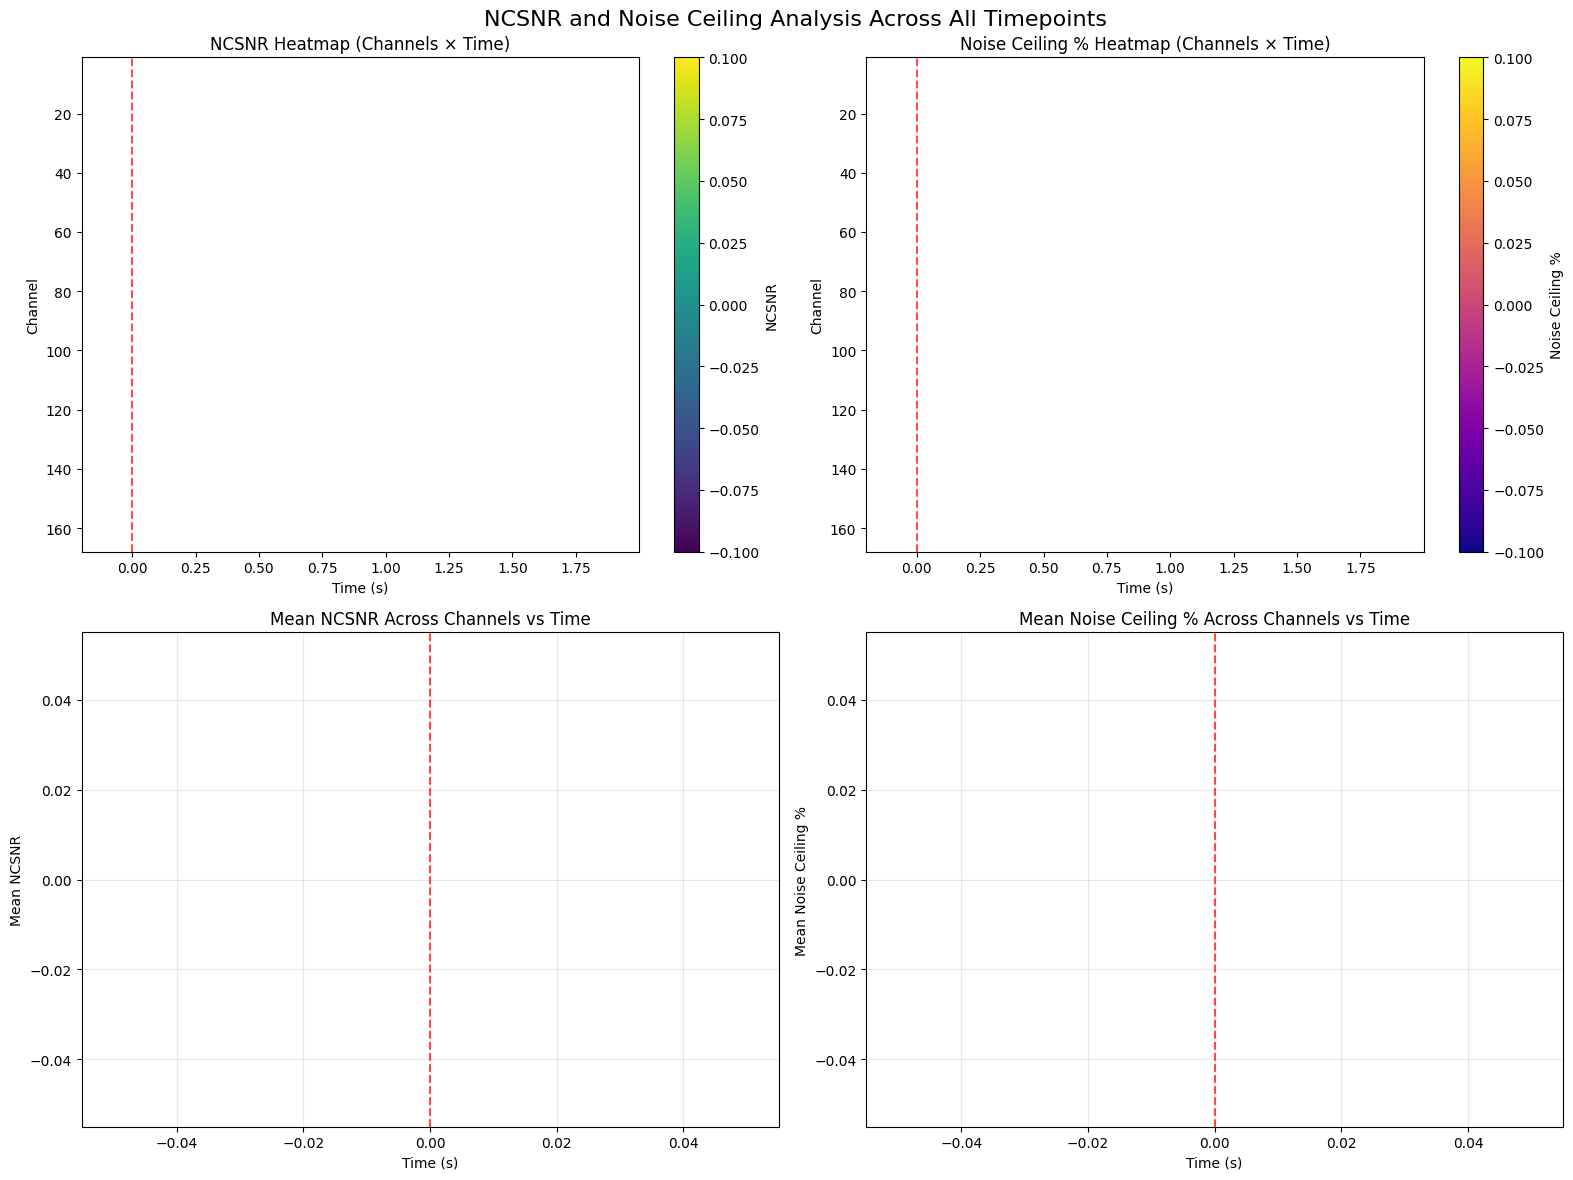


Summary Statistics:
Mean NCSNR across all channels and time: nan
Max NCSNR: nan
Mean Noise Ceiling across all channels and time: nan%
Max Noise Ceiling: nan%
Peak NCSNR time: -0.2ms
Peak NC time: -0.2ms


/tmp/ipykernel_804958/39888123.py:126: RuntimeWarning: Mean of empty slice
  print(f"Mean NCSNR across all channels and time: {np.nanmean(ncsnr_all):.3f}")
/tmp/ipykernel_804958/39888123.py:127: RuntimeWarning: All-NaN slice encountered
  print(f"Max NCSNR: {np.nanmax(ncsnr_all):.3f}")
/tmp/ipykernel_804958/39888123.py:128: RuntimeWarning: Mean of empty slice
  print(f"Mean Noise Ceiling across all channels and time: {np.nanmean(nc_all):.1f}%")
/tmp/ipykernel_804958/39888123.py:129: RuntimeWarning: All-NaN slice encountered
  print(f"Max Noise Ceiling: {np.nanmax(nc_all):.1f}%")


In [55]:
# The filtered_6_repeats has shape (channels, n_filtered_images, time, n_repeats)
# We need to transpose it to (conditions, channels, trials, timepoints) for the noise ceiling function
print(f"Original filtered data shape: {filtered_3_repeats.shape}")
# Transpose from (channels, images, time, repeats) to (images, channels, repeats, time)
data_rep = filtered_3_repeats.transpose(1, 0, 3, 2)
print(f"Transposed data shape: {data_rep.shape}")
print(f"Shape interpretation: ({data_rep.shape[0]} conditions/images, {data_rep.shape[1]} channels, {data_rep.shape[2]} trials/repeats, {data_rep.shape[3]} timepoints)")

# Create a times array for your timepoints
# You'll need to use the appropriate time array from your data
times = ieeg_time

print(f"Times array shape: {times.shape}")

# Compute NCSNR for all timepoints
ncsnr_all, nc_all = compute_ncsnr_all_timepoints(data_rep, times)

rankings = np.flip(np.argsort(ncsnr_all.mean(1)))
# Visualize the results
ncsnr_figs(ncsnr_all[rankings], nc_all[rankings], times)

GPU correlation per channel: 100%|██████████| 168/168 [00:01<00:00, 101.54it/s]


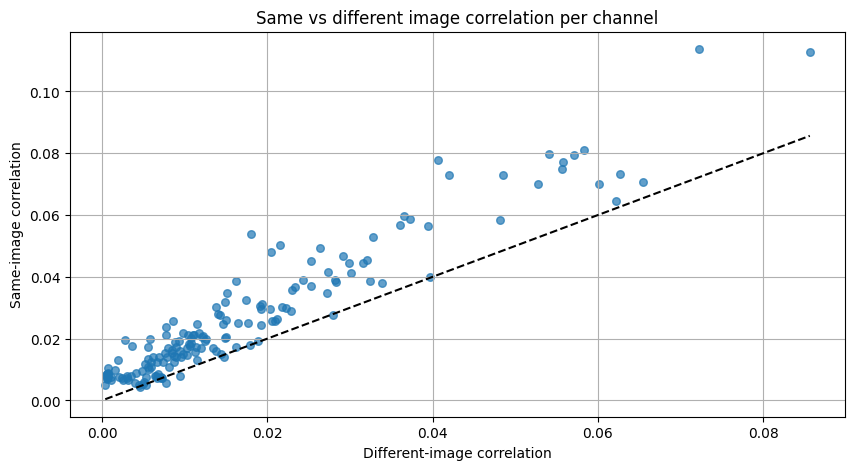

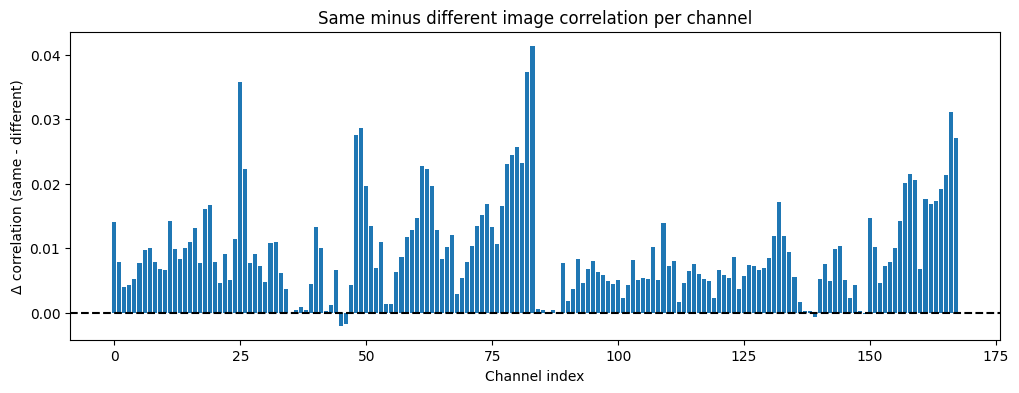

,channel,same_corr,diff_corr,delta
83,LmO-TP16,0.113643,0.072256,0.041387
82,LmO-TP15,0.077919,0.040636,0.037283
25,LmF-aI6,0.053819,0.017980,0.035839
166,RmO-TP15,0.073013,0.041949,0.031064
49,LsT-Pu2,0.050210,0.021593,0.028617


In [12]:
n_trials, n_channels, n_timepoints = ieeg_data.shape
image_names = np.array(image_names)

# --- Step 1: build same/different masks ---
same_mask = image_names[:, None] == image_names[None, :]
np.fill_diagonal(same_mask, False)
diff_mask = ~same_mask

same_mask_t = torch.tensor(same_mask, device=device)
diff_mask_t = torch.tensor(diff_mask, device=device)

# --- Step 2: convert data to torch tensor ---
data_t = torch.tensor(ieeg_data, dtype=torch.float32, device=device)  # (trials, channels, timepoints)

same_corrs = torch.zeros(n_channels, device=device)
diff_corrs = torch.zeros(n_channels, device=device)

# --- Step 3: compute correlations per channel ---
for ch in tqdm(range(n_channels), desc="GPU correlation per channel"):
    x = data_t[:, ch, :]  # (n_trials, n_timepoints)

    # z-score each trial across time
    x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-8)

    # correlation matrix = normalized dot product
    corr = torch.matmul(x, x.T) / x.shape[1]

    # mask & average
    same_corrs[ch] = corr[same_mask_t].mean()
    diff_corrs[ch] = corr[diff_mask_t].mean()

# --- Step 4: move back to CPU for analysis ---
same_corrs = same_corrs.cpu().numpy()
diff_corrs = diff_corrs.cpu().numpy()

# --- Step 5: visualize results ---
plt.figure(figsize=(10, 5))
plt.scatter(diff_corrs, same_corrs, s=30, alpha=0.7)
plt.plot([min(diff_corrs), max(diff_corrs)], [min(diff_corrs), max(diff_corrs)], 'k--')
plt.xlabel("Different-image correlation")
plt.ylabel("Same-image correlation")
plt.title("Same vs different image correlation per channel")
plt.grid(True)
plt.show()

# Δ correlation (same - different)
plt.figure(figsize=(12, 4))
plt.bar(np.arange(n_channels), same_corrs - diff_corrs)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Channel index")
plt.ylabel("Δ correlation (same - different)")
plt.title("Same minus different image correlation per channel")
plt.show()

# --- Step 6: collect results ---
reliability = pd.DataFrame({
    "channel": ieeg_labels["channel_name"].values,
    "same_corr": same_corrs,
    "diff_corr": diff_corrs,
    "delta": same_corrs - diff_corrs
}).sort_values("delta", ascending=False)

display(reliability.head())

In [13]:
# Sort by delta (same_corr - diff_corr) in descending order
reliability_sorted = reliability.sort_values("delta", ascending=False).reset_index(drop=True)

# List of channel names sorted by reliability
sorted_channels = reliability_sorted["channel"].tolist()

print("Top 10 most reliable channels:")
print(sorted_channels[:20])

# print("\nBottom 10 least reliable channels:")
# print(sorted_channels[-10:])


Top 10 most reliable channels:
['LmO-TP16', 'LmO-TP15', 'LmF-aI6', 'RmO-TP15', 'LsT-Pu2', 'LsT-Pu1', 'RmO-TP16', 'LmO-TP13', 'LmO-TP12', 'LmO-TP14', 'LmO-TP11', 'LAP-pC6', 'LAP-pC7', 'LmF-aI7', 'RmO-TP7', 'RmO-TP14', 'RmO-TP8', 'RmO-TP6', 'LAP-pC8', 'LsT-Pu3']


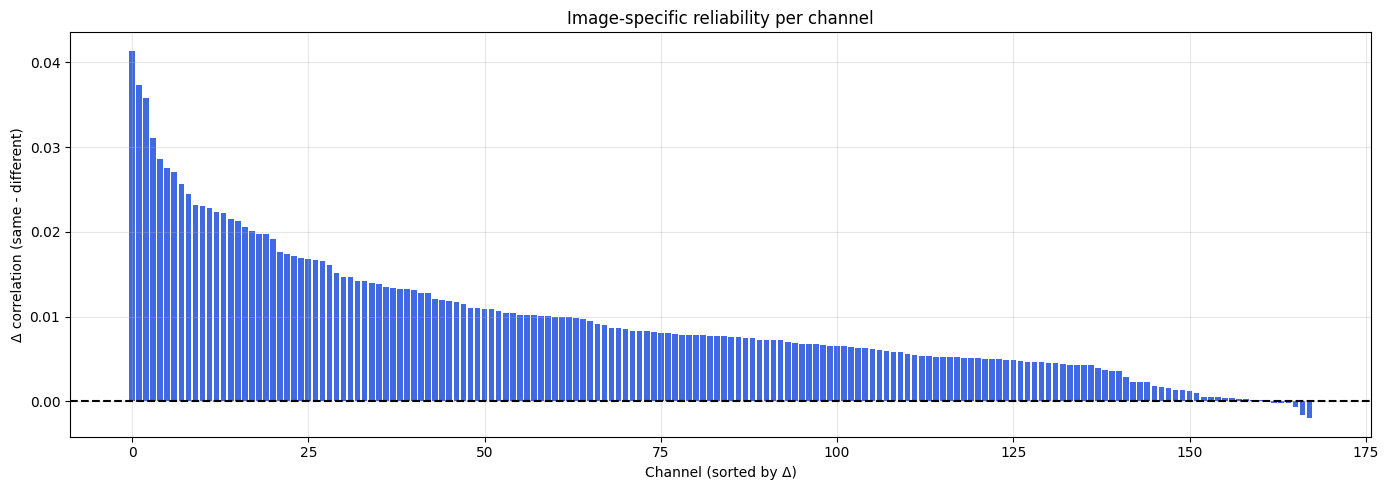

In [14]:
plt.figure(figsize=(14,5))
plt.bar(np.arange(len(reliability_sorted)), reliability_sorted["delta"], color='royalblue')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Channel (sorted by Δ)")
plt.ylabel("Δ correlation (same - different)")
plt.title("Image-specific reliability per channel")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


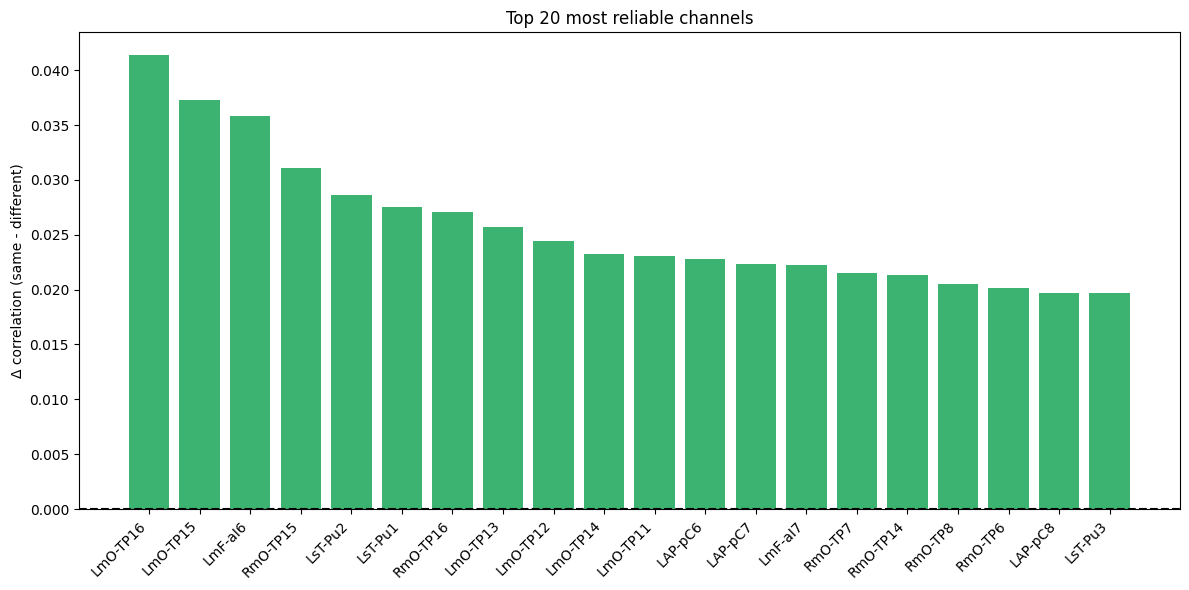

In [15]:
topN = 20
top_channels = reliability_sorted.head(topN)

plt.figure(figsize=(12,6))
plt.bar(top_channels["channel"], top_channels["delta"], color='mediumseagreen')
plt.axhline(0, color='k', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Δ correlation (same - different)")
plt.title(f"Top {topN} most reliable channels")
plt.tight_layout()
plt.show()


In [16]:
mean_data = np.mean(ieeg_data, axis=1)
mean_data.shape

(5600, 512)

In [17]:
mean_data[::560].shape

(10, 512)

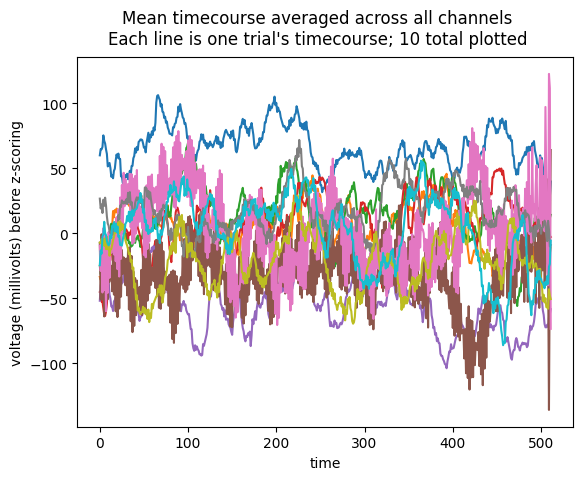

In [18]:
plt.plot(mean_data[::560].T)
plt.suptitle('Mean timecourse averaged across all channels\nEach line is one trial\'s timecourse; 10 total plotted')
plt.xlabel('time')
plt.ylabel('voltage (millivolts) before z-scoring')
plt.show()

In [19]:
n_top_channels = 50
top_idx = np.argsort(reliability['delta'])[::-1][:n_top_channels]
ieeg_data = ieeg_data[:, top_idx, :]
ieeg_labels = ieeg_labels.iloc[top_idx].reset_index(drop=True)

n_time_bins = 16
n_time = ieeg_data.shape[2]
bin_edges = np.linspace(0, n_time, n_time_bins + 1, dtype=int)
binned_data = np.empty((ieeg_data.shape[0], ieeg_data.shape[1], n_time_bins))
binned_time = np.empty(n_time_bins)
for i in range(n_time_bins):
    start, end = bin_edges[i], bin_edges[i + 1]
    binned_data[:, :, i] = ieeg_data[:, :, start:end].mean(axis=2)
    binned_time[i] = ieeg_time[start:end].mean()

ieeg_data = binned_data
ieeg_time = binned_time

In [20]:
print(ieeg_data.shape)
print(ieeg_time.shape)

(5600, 50, 16)
(16,)


In [21]:
# convert images to CLIP embeddings
# want: images x embedding dim matrix
# num images = num images in curriculum file (duplicates ok)
# embedding dim = dimension that corresponds to what we have a clip reconstructor for, sdxl unclip?

Now we have:
1. ieeg_data with shape (trials x channels x timepoints)
2. ground truth clip embeddings with shape (trials x emb_dim)

In [22]:
# Flatten channels and timepoints
ieeg_data_flat = np.reshape(ieeg_data, shape=(ieeg_data.shape[0], ieeg_data.shape[1]*ieeg_data.shape[2]))
print('flattened channels and timepoints dimension')
print(ieeg_data_flat.shape)

flattened channels and timepoints dimension
(5600, 800)


In [23]:
# Train/test split
x_train, x_test, y_train, y_test = train_test_split(
    ieeg_data_flat, clip_image, test_size=0.20, random_state=42
)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(4480, 800) (1120, 800) torch.Size([4480, 1024]) torch.Size([1120, 1024])


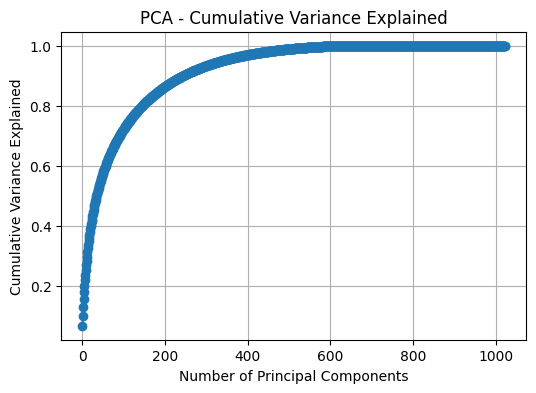

In [24]:
y_train_np = y_train.cpu().numpy()

# Fit PCA without reducing dimensionality to see all components
pca_full = PCA(n_components=y_train_np.shape[1])
pca_full.fit(y_train_np)

# Compute cumulative variance explained
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

# Plot
plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA - Cumulative Variance Explained')
plt.grid(True)
plt.show()

In [25]:
# Z-score across channel/timepoint dimension
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# pca = PCA()
# pca.fit(x_train_scaled)
# explained = pca.explained_variance_ratio_

# cumulative = np.cumsum(explained)
# plt.plot(cumulative)
# plt.xlabel('Number of components')
# plt.ylabel('Cumulative explained variance')
# plt.title('PCA')
# plt.grid(True)
# plt.show()

# n_pcs_90 = np.argmax(cumulative >= 0.90) + 1  # +1 because indices start at 0
# pca = PCA(n_components=n_pcs_90)
# pca.fit(x_train_scaled)

# x_train_scaled = pca.transform(x_train_scaled)
# x_test_scaled = pca.transform(x_test_scaled)
# print(f'reduced x_train and x_test with PCA using {n_pcs_90} components which explains {cumulative[n_pcs_90-1]*100:.2f}% variance')

In [26]:
n_components = 200  # number of PCA components to keep

# Convert to numpy if needed (PCA in scikit-learn works on numpy arrays)
y_train_np = y_train.cpu().numpy()
y_test_np = y_test.cpu().numpy()

# Fit PCA on the training embeddings
pca = PCA(n_components=n_components)
y_train_pca = pca.fit_transform(y_train_np)
y_test_pca = pca.transform(y_test_np)

print("Original y_train shape:", y_train_np.shape)
print("PCA-reduced y_train shape:", y_train_pca.shape)

# Fit ridge regression from x_train -> y_train_pca
ridge = RidgeCV()
ridge.fit(x_train, y_train_pca)

# Predict on test set
y_pred_pca = ridge.predict(x_test)

# Optional: convert predictions back to original 1024-D space
y_pred_orig = pca.inverse_transform(y_pred_pca)

# Evaluate R^2
r2 = r2_score(y_test_np, y_pred_orig)
print("R^2 on test set:", r2)


Original y_train shape: (4480, 1024)
PCA-reduced y_train shape: (4480, 200)
R^2 on test set: -0.1883200133888116


R^2 (coefficient of determination): 0.21


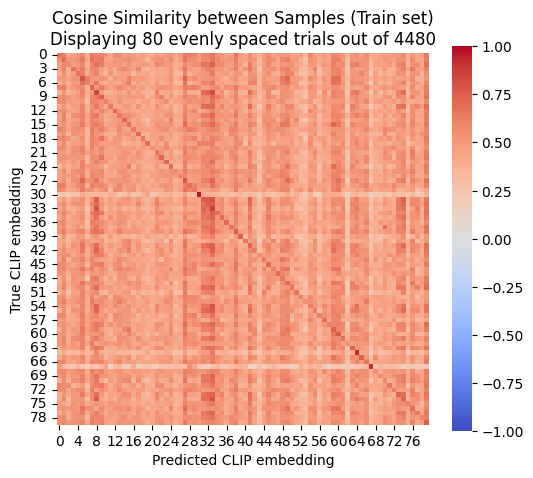

In [27]:
# Set up ridge regression
ridge_model = RidgeCV().fit(x_train_scaled, y_train)
y_pred = ridge_model.predict(x_train_scaled)
coef_of_det = ridge_model.score(x_train_scaled, y_train)

print(f'R^2 (coefficient of determination): {coef_of_det:.2f}')

cossim = cosine_similarity(y_pred[::56], y_train[::56])
plt.figure(figsize=(6,5))
sns.heatmap(cossim, vmin=-1, vmax=1, cmap="coolwarm", square=True)
plt.title("Cosine Similarity between Samples (Train set)\nDisplaying 80 evenly spaced trials out of 4480")
plt.xlabel("Predicted CLIP embedding")
plt.ylabel("True CLIP embedding")
plt.show()

R^2 (coefficient of determination): -0.17


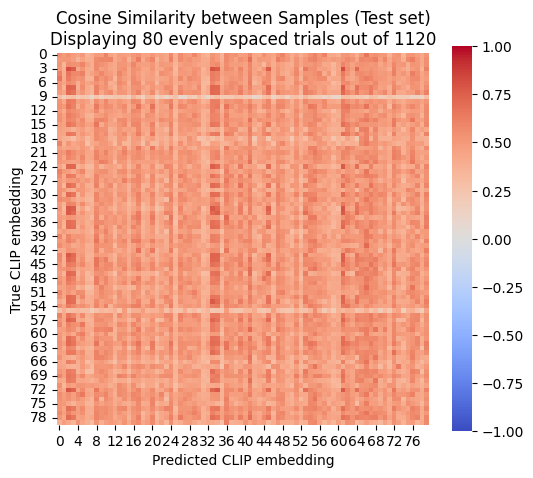

In [28]:
# Set up ridge regression
ridge_model = RidgeCV().fit(x_train_scaled, y_train)
y_pred = ridge_model.predict(x_test_scaled)
coef_of_det = ridge_model.score(x_test_scaled, y_test)

print(f'R^2 (coefficient of determination): {coef_of_det:.2f}')

cossim = cosine_similarity(y_pred[::14], y_test[::14])
plt.figure(figsize=(6,5))
sns.heatmap(cossim, vmin=-1, vmax=1, cmap="coolwarm", square=True)
plt.title("Cosine Similarity between Samples (Test set)\nDisplaying 80 evenly spaced trials out of 1120")
plt.xlabel("Predicted CLIP embedding")
plt.ylabel("True CLIP embedding")
plt.show()

In [29]:
y_pred.shape, y_test.shape

((1120, 1024), torch.Size([1120, 1024]))